# Exercise Form Analysis - Model Training and Evaluation
## Real-Time Exercise Form Analysis Using MediaPipe and Random Forest

This notebook contains the complete pipeline for:
1. Data loading and preparation
2. Feature engineering
3. Model training (Random Forest)
4. Hyperparameter tuning
5. Model evaluation
6. Performance visualization

**Dataset:** 5,804 samples (4,782 bench press + 1,022 shoulder press)  
**Features:** 18 biomechanical features extracted from MediaPipe landmarks

---
## 1. Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import json
from pathlib import Path

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    classification_report, 
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
import sklearn

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model persistence
import joblib

# Utilities
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

✅ Libraries imported successfully!
NumPy version: 2.4.2
Pandas version: 3.0.0
Scikit-learn version: 1.8.0


---
## 2. Define Feature Columns

In [2]:
# 18 Biomechanical Features
FEATURE_COLUMNS = [
    # Elbow Angle Features (7)
    'left_elbow_angle',
    'right_elbow_angle',
    'avg_elbow_angle',
    'elbow_angle_diff',
    'elbow_symmetry',
    'has_flare',
    'extreme_flare',
    
    # Wrist Position Features (5)
    'wrist_x',
    'wrist_y',
    'wrist_z',
    'wrist_x_normalized',
    'wrist_y_position',
    
    # Shoulder Features (4)
    'shoulder_width',
    'shoulder_mid_x',
    'retraction_offset',
    'retraction_normalized',
    
    # Composite Features (2)
    'alignment_score',
    'avg_elbow_angle_squared'
]

print(f"Total features: {len(FEATURE_COLUMNS)}")
print("\nFeature categories:")
print("  - Elbow features: 7")
print("  - Wrist features: 5")
print("  - Shoulder features: 4")
print("  - Composite features: 2")

Total features: 18

Feature categories:
  - Elbow features: 7
  - Wrist features: 5
  - Shoulder features: 4
  - Composite features: 2


---
## 3. Load and Prepare Data

### 3.1 Load Bench Press Data (JSON)

In [3]:
print("Loading bench press data from JSON...")

json_file = Path('data/biomechanical_features_augmented.json')

with open(json_file, 'r') as f:
    json_data = json.load(f)

print(f"\nDataset metadata:")
print(f"  Total samples: {json_data.get('total_samples', 'N/A')}")
print(f"  Original samples: {json_data.get('original_samples', 'N/A')}")
print(f"  Augmentation factor: {json_data.get('augmentation_factor', 'N/A')}x")
print(f"  Features per sample: {json_data.get('features_per_sample', 'N/A')}")

# Extract data
bench_data = json_data['data']

# Convert to DataFrame
bench_rows = []
for item in bench_data:
    row = {}
    
    # Map features
    for feat in FEATURE_COLUMNS:
        if feat in item:
            row[feat] = item[feat]
        # Handle different naming conventions
        elif feat == 'elbow_angle_diff' and 'elbow_asymmetry' in item:
            row[feat] = item['elbow_asymmetry']
        elif feat == 'has_flare' and 'excessive_elbow_flare' in item:
            row[feat] = item['excessive_elbow_flare']
        elif feat == 'extreme_flare' and 'extreme_elbow_flare' in item:
            row[feat] = item['extreme_elbow_flare']
    
    # Convert label
    label_val = item.get('label', 'correct')
    row['label'] = 1 if label_val == 'correct' else 0
    row['exercise'] = 'bench_press'
    
    # Only add if we have most features
    if len(row) >= 15:
        bench_rows.append(row)

df_bench = pd.DataFrame(bench_rows)

# Fill missing columns with 0
for feat in FEATURE_COLUMNS:
    if feat not in df_bench.columns:
        df_bench[feat] = 0

print(f"\n✅ Bench press data loaded: {len(df_bench)} samples")
print(f"   Correct: {len(df_bench[df_bench['label']==1])} ({len(df_bench[df_bench['label']==1])/len(df_bench)*100:.1f}%)")
print(f"   Incorrect: {len(df_bench[df_bench['label']==0])} ({len(df_bench[df_bench['label']==0])/len(df_bench)*100:.1f}%)")

Loading bench press data from JSON...

Dataset metadata:
  Total samples: 4782
  Original samples: 1594
  Augmentation factor: 3x
  Features per sample: 18

✅ Bench press data loaded: 4782 samples
   Correct: 2967 (62.0%)
   Incorrect: 1815 (38.0%)


### 3.2 Load Shoulder Press Data (CSV)

In [4]:
print("Loading shoulder press data from CSV...")

csv_file = Path('data/shoulder_press_features.csv')
df_shoulder = pd.read_csv(csv_file)
df_shoulder['exercise'] = 'shoulder_press'

print(f"\n✅ Shoulder press data loaded: {len(df_shoulder)} samples")
print(f"   Correct: {len(df_shoulder[df_shoulder['label']==1])} ({len(df_shoulder[df_shoulder['label']==1])/len(df_shoulder)*100:.1f}%)")
print(f"   Incorrect: {len(df_shoulder[df_shoulder['label']==0])} ({len(df_shoulder[df_shoulder['label']==0])/len(df_shoulder)*100:.1f}%)")

Loading shoulder press data from CSV...

✅ Shoulder press data loaded: 1022 samples
   Correct: 444 (43.4%)
   Incorrect: 578 (56.6%)


### 3.3 Combine Datasets

In [5]:
print("Combining bench press and shoulder press datasets...")

# Combine
df_combined = pd.concat(
    [df_bench[FEATURE_COLUMNS + ['label', 'exercise']], 
     df_shoulder[FEATURE_COLUMNS + ['label', 'exercise']]], 
    ignore_index=True
)

print(f"\n{'='*60}")
print("COMBINED DATASET STATISTICS")
print(f"{'='*60}")
print(f"\nTotal samples: {len(df_combined)}")
print(f"\nBy Exercise:")
print(df_combined['exercise'].value_counts())
print(f"\nBy Label:")
print(f"  Correct (1): {len(df_combined[df_combined['label']==1])} ({len(df_combined[df_combined['label']==1])/len(df_combined)*100:.1f}%)")
print(f"  Incorrect (0): {len(df_combined[df_combined['label']==0])} ({len(df_combined[df_combined['label']==0])/len(df_combined)*100:.1f}%)")

# Display first few rows
print(f"\nFirst 3 samples:")
display(df_combined[FEATURE_COLUMNS + ['label', 'exercise']].head(3))

# Check for missing values
missing = df_combined[FEATURE_COLUMNS].isnull().sum()
if missing.sum() > 0:
    print(f"\n⚠️  Missing values detected:")
    print(missing[missing > 0])
else:
    print(f"\n✅ No missing values detected")

Combining bench press and shoulder press datasets...

COMBINED DATASET STATISTICS

Total samples: 5804

By Exercise:
exercise
bench_press       4782
shoulder_press    1022
Name: count, dtype: int64

By Label:
  Correct (1): 3411 (58.8%)
  Incorrect (0): 2393 (41.2%)

First 3 samples:


,left_elbow_angle,right_elbow_angle,avg_elbow_angle,elbow_angle_diff,elbow_symmetry,has_flare,extreme_flare,wrist_x,wrist_y,wrist_z,wrist_x_normalized,wrist_y_position,shoulder_width,shoulder_mid_x,retraction_offset,retraction_normalized,alignment_score,avg_elbow_angle_squared,label,exercise
0,169.886789,167.796204,168.841497,2.090584,0.987694,1,1,0.541643,0.452367,0.447274,4.639874,0.452367,0.116737,0.538029,0.001758,0.015057,0.003614,28507.450948,1,bench_press
1,168.316176,167.710777,168.730829,2.071767,0.982779,1,1,0.538474,0.453820,0.441741,2.000000,0.450403,0.116064,0.536235,0.001758,0.015243,0.003589,28793.180585,1,bench_press
2,172.148789,168.851424,170.106540,2.016952,0.999584,1,1,0.540518,0.462326,0.432258,2.000000,0.446579,0.119559,0.547395,0.001704,0.014615,0.003415,28788.042678,1,bench_press



✅ No missing values detected


### 3.4 Exploratory Data Analysis

Statistical Summary of Features:


,left_elbow_angle,right_elbow_angle,avg_elbow_angle,elbow_angle_diff,elbow_symmetry,has_flare,extreme_flare,wrist_x,wrist_y,wrist_z,wrist_x_normalized,wrist_y_position,shoulder_width,shoulder_mid_x,retraction_offset,retraction_normalized,alignment_score,avg_elbow_angle_squared
count,5804.000000,5804.000000,5804.000000,5804.000000,5804.000000,5804.000000,5804.000000,5804.000000,5804.000000,5804.000000,5804.000000,5804.000000,5804.000000,5804.000000,5804.000000,5804.000000,5.804000e+03,5804.000000
mean,118.499837,120.667388,119.606733,11.331562,15.844358,0.703653,0.579600,0.492036,0.493423,0.235718,2.351328,0.408127,0.118895,0.489028,0.003721,0.034812,1.645352e+01,17086.123069
std,54.242000,52.956463,52.771407,15.360113,34.135273,0.456685,0.493666,0.033749,0.113205,0.328327,2.075828,0.242540,0.017843,0.031085,0.003679,0.053159,3.585474e+01,11132.377670
min,0.882247,0.083434,0.941719,0.000877,-90.550573,0.000000,0.000000,0.415613,0.094776,-1.035005,-0.500457,-0.399210,0.009125,0.421073,0.000000,0.000000,4.470348e-08,0.886835
25%,61.286847,73.680016,69.453332,2.184083,0.855766,0.000000,0.000000,0.465284,0.426984,0.168770,2.000000,0.410340,0.112747,0.464200,0.000829,0.007300,1.798821e-03,4845.350160
50%,139.305398,138.885761,140.136320,4.929215,0.969932,1.000000,1.000000,0.490781,0.472175,0.335270,2.000000,0.456338,0.117648,0.490026,0.003172,0.027619,4.626402e-03,19605.344578
75%,167.595877,168.673146,166.967979,13.789863,0.996193,1.000000,1.000000,0.507962,0.580751,0.441914,3.744931,0.556420,0.124642,0.504166,0.005561,0.047802,1.240663e-02,27908.167609
max,180.000000,180.000000,180.000000,155.084454,99.973907,1.000000,1.000000,0.650831,1.050383,1.150617,57.011864,1.030231,0.222920,0.576635,0.053783,1.412773,9.996637e+01,33059.299549



Computing correlation matrix...


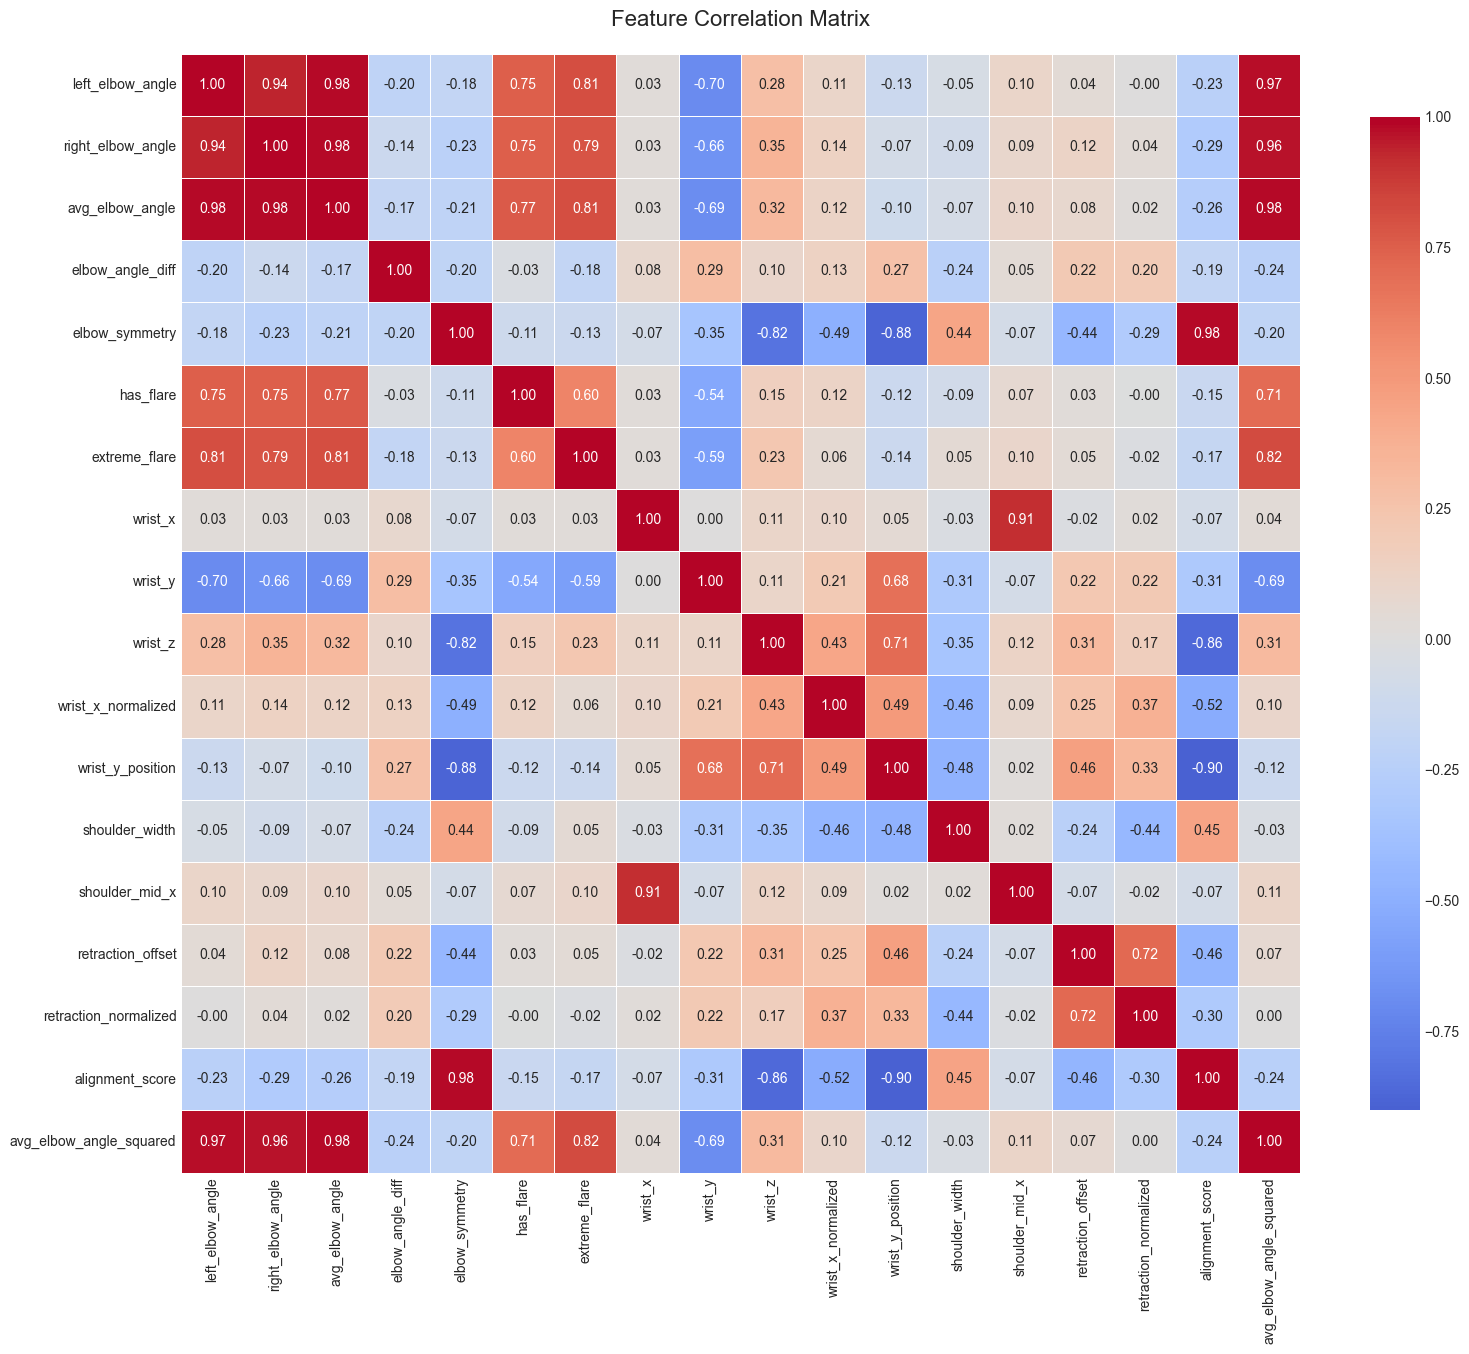

✅ Correlation matrix saved as 'correlation_matrix.png'


In [6]:
# Statistical summary
print("Statistical Summary of Features:")
display(df_combined[FEATURE_COLUMNS].describe())

# Correlation matrix
print("\nComputing correlation matrix...")
corr_matrix = df_combined[FEATURE_COLUMNS].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Correlation matrix saved as 'correlation_matrix.png'")

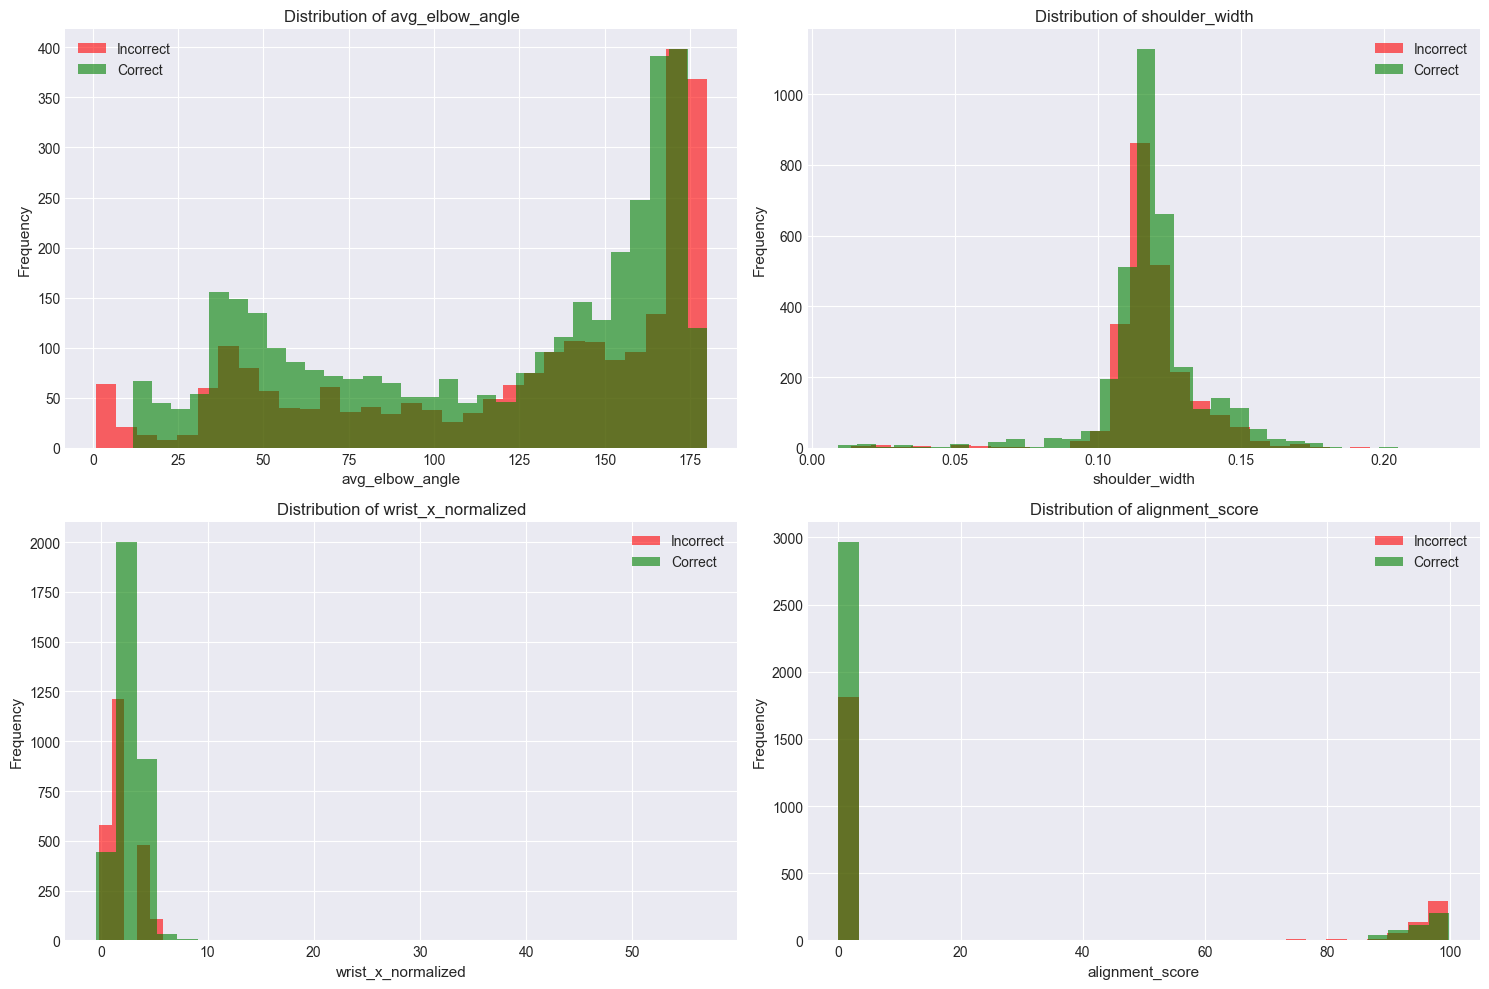

✅ Feature distributions saved as 'feature_distributions.png'


In [7]:
# Distribution of key features by label
key_features = ['avg_elbow_angle', 'shoulder_width', 'wrist_x_normalized', 'alignment_score']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    df_combined[df_combined['label']==0][feature].hist(
        bins=30, alpha=0.6, label='Incorrect', ax=axes[idx], color='red'
    )
    df_combined[df_combined['label']==1][feature].hist(
        bins=30, alpha=0.6, label='Correct', ax=axes[idx], color='green'
    )
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].legend()
    axes[idx].set_title(f'Distribution of {feature}', fontsize=12)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Feature distributions saved as 'feature_distributions.png'")

---
## 4. Data Preparation for Training

### 4.1 Split Features and Labels

In [8]:
print("Preparing features and labels...")

X = df_combined[FEATURE_COLUMNS].values
y = df_combined['label'].values

print(f"\nFeature matrix (X): {X.shape}")
print(f"Label vector (y): {y.shape}")
print(f"\nLabel distribution:")
print(f"  Class 0 (Incorrect): {np.sum(y==0)} ({np.sum(y==0)/len(y)*100:.1f}%)")
print(f"  Class 1 (Correct): {np.sum(y==1)} ({np.sum(y==1)/len(y)*100:.1f}%)")

Preparing features and labels...

Feature matrix (X): (5804, 18)
Label vector (y): (5804,)

Label distribution:
  Class 0 (Incorrect): 2393 (41.2%)
  Class 1 (Correct): 3411 (58.8%)


### 4.2 Train-Test Split (80/20)

In [9]:
print("Splitting data into training and test sets (80/20)...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,           # 20% for testing
    random_state=RANDOM_STATE,  # Reproducibility
    stratify=y               # Maintain class distribution
)

print(f"\n{'='*60}")
print("TRAIN-TEST SPLIT")
print(f"{'='*60}")
print(f"\nTraining set: {X_train.shape[0]} samples (80%)")
print(f"  Incorrect: {np.sum(y_train==0)} ({np.sum(y_train==0)/len(y_train)*100:.1f}%)")
print(f"  Correct: {np.sum(y_train==1)} ({np.sum(y_train==1)/len(y_train)*100:.1f}%)")

print(f"\nTest set: {X_test.shape[0]} samples (20%)")
print(f"  Incorrect: {np.sum(y_test==0)} ({np.sum(y_test==0)/len(y_test)*100:.1f}%)")
print(f"  Correct: {np.sum(y_test==1)} ({np.sum(y_test==1)/len(y_test)*100:.1f}%)")

print(f"\n✅ Stratification maintained class balance")

Splitting data into training and test sets (80/20)...

TRAIN-TEST SPLIT

Training set: 4643 samples (80%)
  Incorrect: 1914 (41.2%)
  Correct: 2729 (58.8%)

Test set: 1161 samples (20%)
  Incorrect: 479 (41.3%)
  Correct: 682 (58.7%)

✅ Stratification maintained class balance


### 4.3 Feature Normalization (StandardScaler)

In [10]:
print("Normalizing features using StandardScaler...")
print("Formula: z = (x - μ) / σ")
print("  Where μ = mean, σ = standard deviation")

scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using training statistics
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Features normalized")
print(f"\nTraining set statistics (after scaling):")
print(f"  Mean: {X_train_scaled.mean():.6f} (should be ~0)")
print(f"  Std: {X_train_scaled.std():.6f} (should be ~1)")

print(f"\nTest set statistics (after scaling):")
print(f"  Mean: {X_test_scaled.mean():.6f}")
print(f"  Std: {X_test_scaled.std():.6f}")

Normalizing features using StandardScaler...
Formula: z = (x - μ) / σ
  Where μ = mean, σ = standard deviation

✅ Features normalized

Training set statistics (after scaling):
  Mean: 0.000000 (should be ~0)
  Std: 1.000000 (should be ~1)

Test set statistics (after scaling):
  Mean: 0.006706
  Std: 1.044717


---
## 5. Model Training

### 5.1 Train Final Optimized Model

In [22]:
final_model = RandomForestClassifier(
    n_estimators=300,        # Much more reasonable
    max_depth=15,            # Limit tree depth — key fix
    min_samples_split=10,    # Require more samples to split
    min_samples_leaf=4,      # Require more samples at leaves
    max_features='sqrt',
    bootstrap=True,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Use CV to get a honest estimate of generalization
cv_scores = cross_val_score(final_model, X_train_scaled, y_train, cv=5, scoring='f1_weighted')
print(f"CV F1 scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Then fit on full training data
final_model.fit(X_train_scaled, y_train)

# Compare train vs test accuracy
print(f"Train accuracy: {final_model.score(X_train_scaled, y_train):.4f}")
print(f"Test accuracy:  {final_model.score(X_test_scaled, y_test):.4f}")

CV F1 scores: [0.83998603 0.87908106 0.86846053 0.86020482 0.86300766]
Mean: 0.8621 ± 0.0128
Train accuracy: 0.9802
Test accuracy:  0.8889


---
## 6. Model Evaluation

### 6.1 Training and Test Accuracy

In [23]:
print("Evaluating model performance...")

# Predictions
y_train_pred = final_model.predict(X_train_scaled)
y_test_pred = final_model.predict(X_test_scaled)

# Probabilities
y_train_proba = final_model.predict_proba(X_train_scaled)[:, 1]
y_test_proba = final_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\n{'='*60}")
print("MODEL PERFORMANCE")
print(f"{'='*60}")
print(f"\nTraining Accuracy: {train_accuracy*100:.2f}%")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Generalization Gap: {(train_accuracy - test_accuracy)*100:.2f}%")

Evaluating model performance...

MODEL PERFORMANCE

Training Accuracy: 98.02%
Test Accuracy: 88.89%
Generalization Gap: 9.13%


### 6.2 Cross-Validation Scores

In [24]:
print("Performing 5-fold cross-validation...")

cv_scores = cross_val_score(
    final_model, 
    X_train_scaled, 
    y_train, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1
)

print(f"\n{'='*60}")
print("CROSS-VALIDATION RESULTS (5-Fold)")
print(f"{'='*60}")
print(f"\nIndividual fold scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score*100:.2f}%")

print(f"\nMean CV Accuracy: {cv_scores.mean()*100:.2f}%")
print(f"Standard Deviation: ±{cv_scores.std()*100:.2f}%")

Performing 5-fold cross-validation...

CROSS-VALIDATION RESULTS (5-Fold)

Individual fold scores:
  Fold 1: 84.07%
  Fold 2: 87.94%
  Fold 3: 86.87%
  Fold 4: 86.10%
  Fold 5: 86.31%

Mean CV Accuracy: 86.26%
Standard Deviation: ±1.27%


### 6.3 Classification Report

In [25]:
print(f"\n{'='*60}")
print("CLASSIFICATION REPORT (Test Set)")
print(f"{'='*60}")
print()
print(classification_report(
    y_test, 
    y_test_pred, 
    target_names=['Incorrect Form', 'Correct Form'],
    digits=4
))


CLASSIFICATION REPORT (Test Set)

                precision    recall  f1-score   support

Incorrect Form     0.8772    0.8497    0.8632       479
  Correct Form     0.8967    0.9164    0.9065       682

      accuracy                         0.8889      1161
     macro avg     0.8869    0.8831    0.8848      1161
  weighted avg     0.8886    0.8889    0.8886      1161



### 6.4 Confusion Matrix


CONFUSION MATRIX (Test Set)

                Predicted
              Incorrect  Correct
Actual Incorrect     407        72
       Correct        57       625

Breakdown:
  True Negatives (TN): 407
  False Positives (FP): 72
  False Negatives (FN): 57
  True Positives (TP): 625


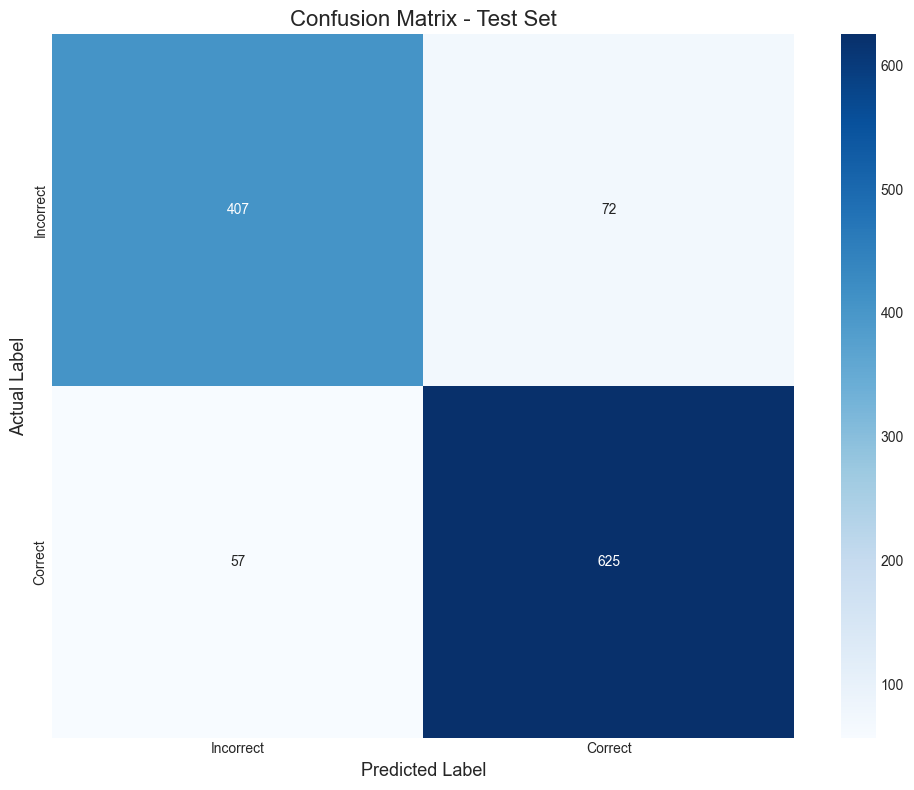


✅ Confusion matrix saved


In [26]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

print(f"\n{'='*60}")
print("CONFUSION MATRIX (Test Set)")
print(f"{'='*60}")
print()
print("                Predicted")
print("              Incorrect  Correct")
print(f"Actual Incorrect    {cm[0,0]:4d}      {cm[0,1]:4d}")
print(f"       Correct      {cm[1,0]:4d}      {cm[1,1]:4d}")

print(f"\nBreakdown:")
print(f"  True Negatives (TN): {cm[0,0]}")
print(f"  False Positives (FP): {cm[0,1]}")
print(f"  False Negatives (FN): {cm[1,0]}")
print(f"  True Positives (TP): {cm[1,1]}")

# Visualize
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Incorrect', 'Correct'],
            yticklabels=['Incorrect', 'Correct'])
plt.title('Confusion Matrix - Test Set', fontsize=16)
plt.ylabel('Actual Label', fontsize=13)
plt.xlabel('Predicted Label', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

print("\n✅ Confusion matrix saved")

### 6.5 ROC Curve

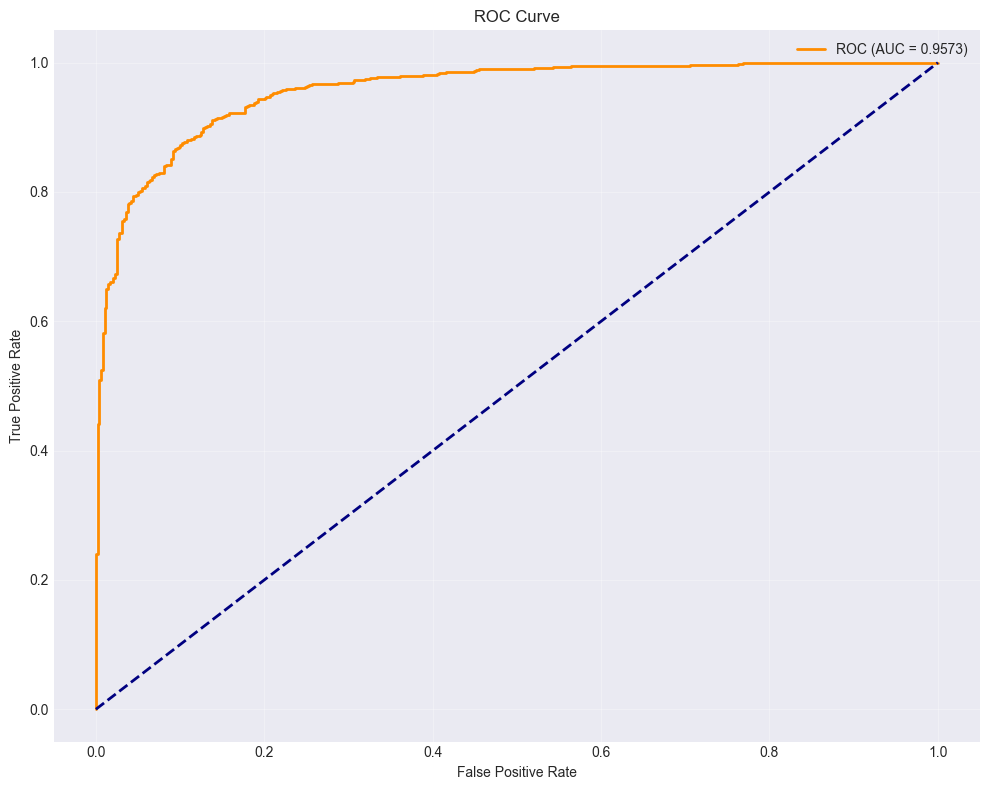


ROC AUC: 0.9573


In [27]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300)
plt.show()

print(f"\nROC AUC: {roc_auc:.4f}")

---
## 7. Feature Importance


Top 10 Features:
  avg_elbow_angle_squared       :  9.90%
  shoulder_width                :  9.13%
  wrist_y_position              :  7.56%
  wrist_x                       :  7.49%
  avg_elbow_angle               :  6.97%
  wrist_z                       :  6.64%
  shoulder_mid_x                :  6.52%
  wrist_y                       :  6.33%
  right_elbow_angle             :  6.22%
  left_elbow_angle              :  6.05%


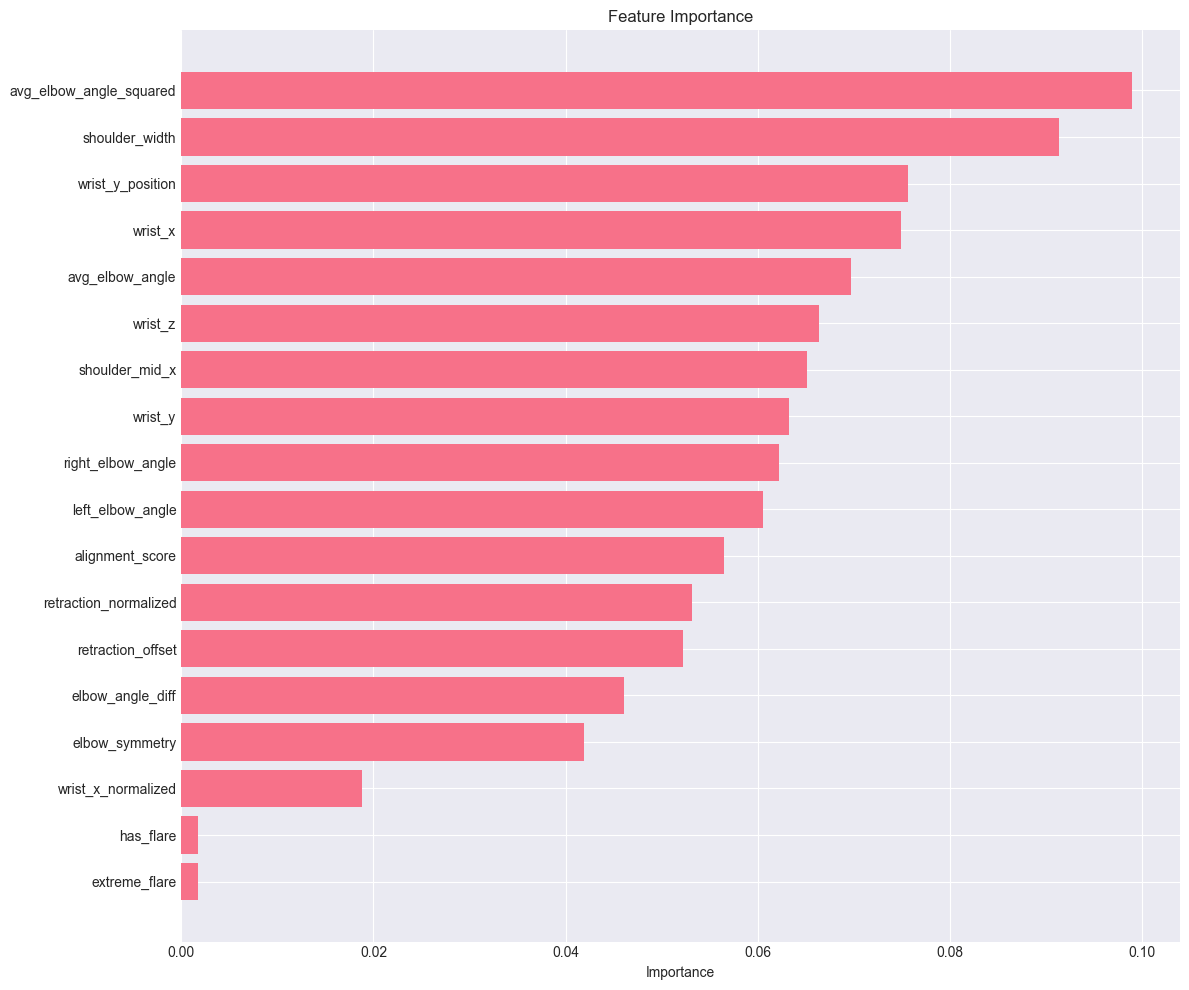

In [28]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Features:")
for idx, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']:30s}: {row['importance']*100:5.2f}%")

# Visualize
plt.figure(figsize=(12, 10))
plt.barh(range(len(feature_importance)), feature_importance['importance'])
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

---
## 8. Save Model

In [29]:
print("Saving model...")

models_dir = Path('models')
models_dir.mkdir(exist_ok=True)

joblib.dump(final_model, models_dir / 'combined_exercise_model.pkl')
joblib.dump(scaler, models_dir / 'combined_exercise_scaler.pkl')
joblib.dump(final_model, models_dir / 'random_forest_tuned.joblib')
joblib.dump(scaler, models_dir / 'feature_scaler_tuned.joblib')

print("\n✅ Model saved!")

Saving model...

✅ Model saved!


---
## 9. Summary

In [30]:
print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"\nDataset: {len(df_combined)} samples")
print(f"Training: {len(X_train)} | Test: {len(X_test)}")
print(f"\nPerformance:")
print(f"  Training Accuracy: {train_accuracy*100:.2f}%")
print(f"  Test Accuracy: {test_accuracy*100:.2f}%")
print(f"  CV Accuracy: {cv_scores.mean()*100:.2f}% ±{cv_scores.std()*100:.2f}%")
print(f"  ROC AUC: {roc_auc:.4f}")
print(f"\nConfusion Matrix:")
print(f"  TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}")
print(f"\n✅ Complete!")


FINAL SUMMARY

Dataset: 5804 samples
Training: 4643 | Test: 1161

Performance:
  Training Accuracy: 98.02%
  Test Accuracy: 88.89%
  CV Accuracy: 86.26% ±1.27%
  ROC AUC: 0.9573

Confusion Matrix:
  TN=407 FP=72 FN=57 TP=625

✅ Complete!
